Este é um grafico de e-commerce retirado do Kanggle.

Meu objetivo é analisa-lo e achar os pontos fortes de vendas dessa empresa.

In [ ]:
import pandas as pd

ecomerce = '/content/vendas_ecommerce.csv'
df = pd.read_csv(ecomerce)
df.head()

,id_pedido,data_pedido,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_bruta,desconto,receita_liquida
0,1,2025-11-19,Cliente_99,Notebook,Acessórios,Sudeste,3,1172.91,3518.73,0.22,2744.61
1,2,2025-04-17,Cliente_5,Monitor,Acessórios,Sudeste,3,2144.38,6433.14,0.12,5661.16
2,3,2025-04-24,Cliente_43,Monitor,Periféricos,Norte,2,2430.61,4861.22,0.12,4277.87
3,4,2025-08-13,Cliente_18,Teclado,Eletrônicos,Sul,4,3658.80,14635.20,0.07,13610.74
4,5,2025-04-07,Cliente_90,Teclado,Periféricos,Nordeste,2,2989.82,5979.64,0.05,5680.66


Qual região gera maior receita liquida ?

In [ ]:
compra_regiao = df.groupby('regiao')['receita_liquida'].sum().sort_values(ascending=False)
compra_regiao

,receita_liquida
regiao,
Sul,969121.75
Centro-Oeste,900382.50
Nordeste,866065.78
Norte,845225.18
Sudeste,836635.01


grafico da região

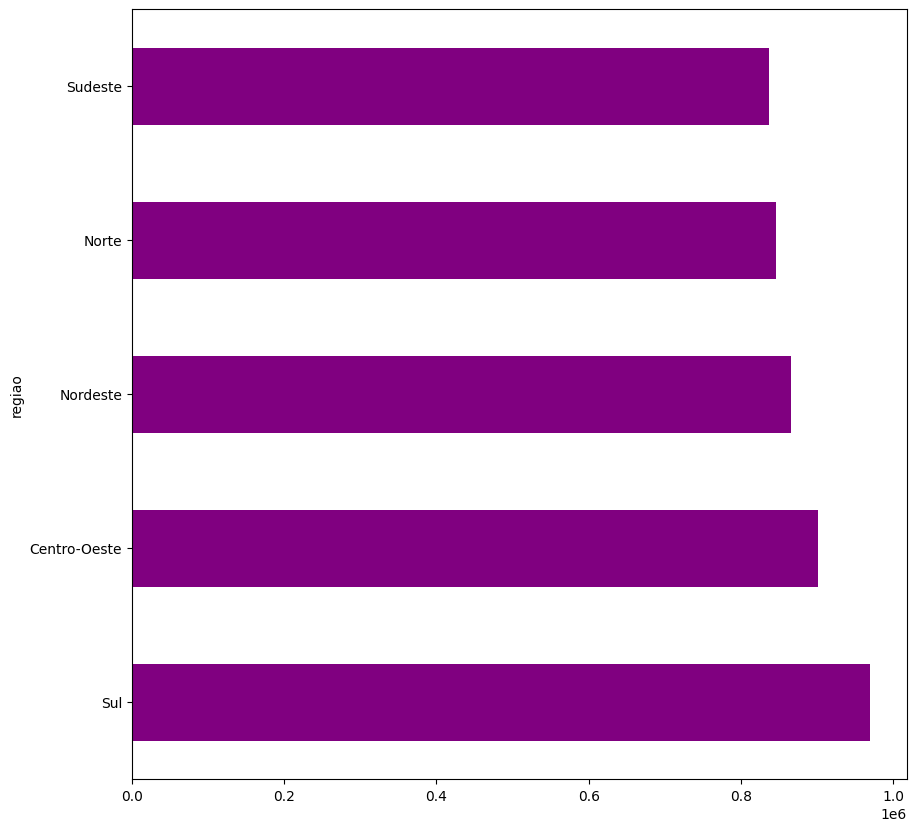

In [ ]:
compra_regiao.plot(kind='barh', figsize=(10, 10), color ='purple');


Qual produo gera a maior receita liquida ?

In [ ]:
df.groupby('produto')['receita_liquida'].sum().sort_values(ascending=False).map('{:,.2f}'.format)

,receita_liquida
produto,
Notebook,"817,635.03"
Teclado,"793,679.13"
Monitor,"783,567.12"
Cadeira Gamer,"681,710.73"
Mouse,"677,851.13"
Headset,"662,987.08"


Qual cadegoria gera a maior receita liquida ?

In [ ]:
df.groupby('categoria')['receita_liquida'].sum().sort_values(ascending=False).map('{:,.2f}'.format)

,receita_liquida
categoria,
Eletrônicos,"1,617,874.21"
Periféricos,"1,436,622.42"
Acessórios,"1,362,933.59"


Dentro da categoria "Eletrônicos" qual produto gera maior receita liquida ?

In [ ]:
df.query("categoria == 'Eletrônicos'").groupby('produto')['receita_liquida'].sum().sort_values(ascending=False).map('{:,.2f}'.format)

,receita_liquida
produto,
Teclado,"327,832.42"
Mouse,"305,004.14"
Monitor,"295,540.29"
Notebook,"245,430.18"
Headset,"222,979.53"
Cadeira Gamer,"221,087.65"


Dos eletronicos quais são os 10 maiores compradores??

In [ ]:
top10_clientes = df.query("categoria == 'Eletrônicos'").groupby(['cliente','produto'])['receita_liquida'].sum().sort_values(ascending=False).head(10)
top10_clientes

,,receita_liquida
cliente,produto,
Cliente_61,Monitor,26936.66
Cliente_68,Cadeira Gamer,23849.15
Cliente_37,Headset,22582.25
Cliente_96,Teclado,22201.35
Cliente_66,Monitor,21712.93
Cliente_37,Monitor,21495.98
Cliente_91,Mouse,19991.33
Cliente_34,Teclado,19919.24
Cliente_38,Monitor,19212.58


Grafico dos compradores

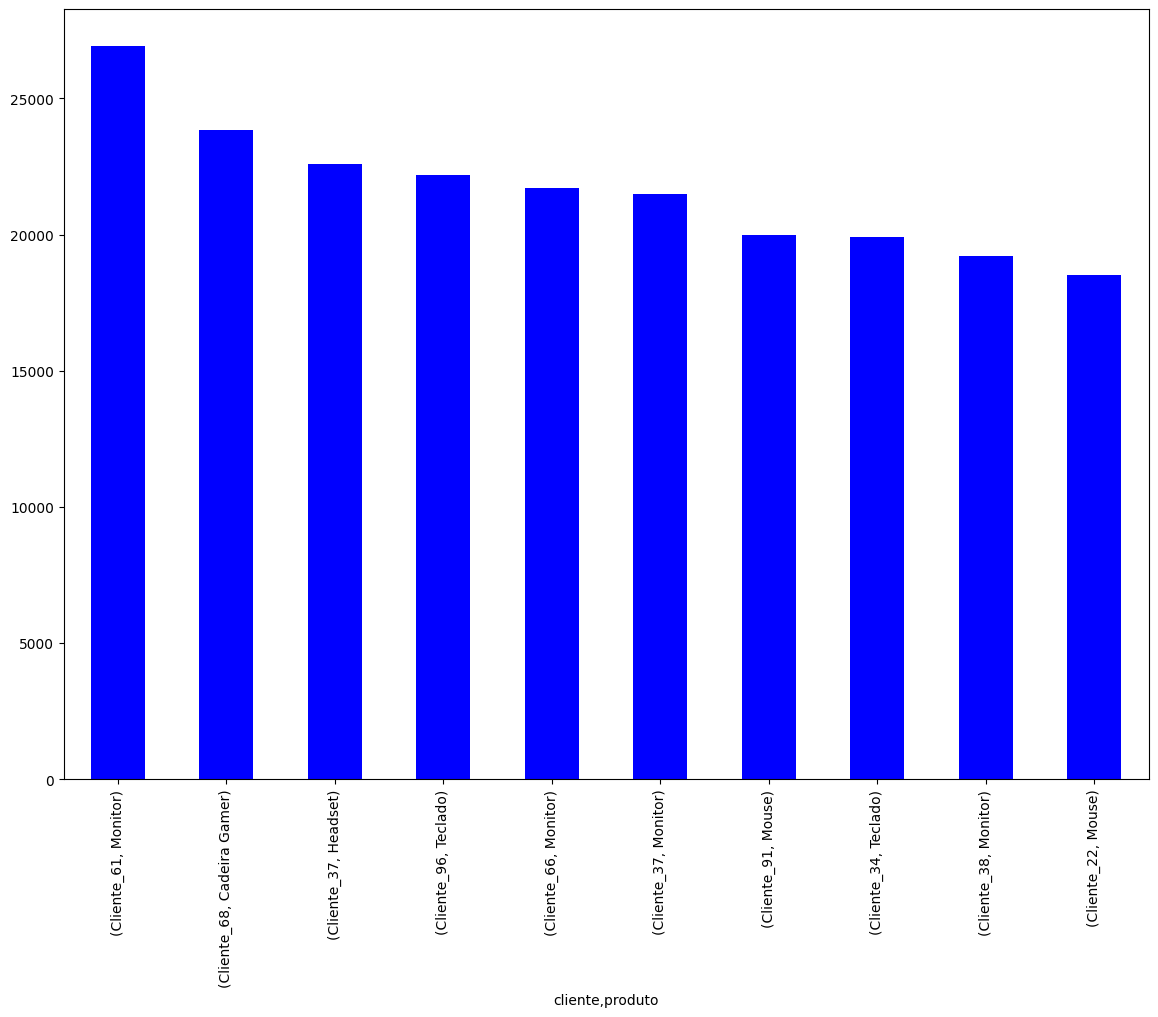

In [ ]:
top10_clientes.plot(kind='bar', figsize=(14, 10), color ='blue');

Quais são os 10 maiores compradores independente da categoria

In [ ]:
df.groupby('cliente')['receita_liquida'].sum().sort_values(ascending=False).map('{:,.2f}'.format).head(10)

,receita_liquida
cliente,
Cliente_48,"113,058.51"
Cliente_62,"96,875.85"
Cliente_66,"95,059.67"
Cliente_51,"90,786.50"
Cliente_34,"80,471.86"
Cliente_81,"79,412.33"
Cliente_11,"76,265.13"
Cliente_35,"75,348.81"
Cliente_67,"74,117.97"


De qual região o Cliente 48 faz parte ?

In [ ]:
df.query("cliente == 'Cliente_48'").groupby('cliente')['regiao'].unique()

,regiao
cliente,
Cliente_48,"[Centro-Oeste, Sul, Sudeste, Nordeste, Norte]"


Quais produtos o cliete_48 mais compra ?

In [ ]:
df.query("cliente == 'Cliente_48'").groupby(['cliente','produto'])['receita_liquida'].sum().sort_values(ascending=False).map('{:,.2f}'.format)

cliente     produto 
Cliente_48  Notebook    34,732.23
            Headset     31,430.09
            Teclado     25,363.55
            Monitor     20,986.73
            Mouse          545.91
Name: receita_liquida, dtype: object

Quais sãos os clientes que gera maior receita por região ?

In [ ]:
maiores_clientes = (df.groupby(['regiao', 'cliente'])['receita_liquida'].sum().reset_index())

maiores_por_regiao = maiores_clientes.loc[maiores_clientes.groupby('regiao')['receita_liquida'].idxmax()]

maiores_por_regiao.sort_values(by='receita_liquida', ascending=False)

,regiao,cliente,receita_liquida
373,Sul,Cliente_66,48336.56
93,Nordeste,Cliente_22,45370.38
205,Norte,Cliente_62,39486.16
260,Sudeste,Cliente_34,38707.71
10,Centro-Oeste,Cliente_20,34409.38


O que o cliente 66 compra dos nossos produtos ?

In [ ]:
df.query("cliente == 'Cliente_66'").groupby(['cliente','produto'])['receita_liquida'].sum().sort_values(ascending=False).map('{:,.2f}'.format)

cliente     produto      
Cliente_66  Monitor          37,485.39
            Mouse            25,140.85
            Teclado          21,113.56
            Cadeira Gamer     6,280.44
            Notebook          5,039.43
Name: receita_liquida, dtype: object

Ticket medio

In [ ]:
df['ticket_medio'] = df['receita_liquida'] / df['quantidade']
df

,id_pedido,data_pedido,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_bruta,desconto,receita_liquida,ticket_medio
0,1,2025-11-19,Cliente_99,Notebook,Acessórios,Sudeste,3,1172.91,3518.73,0.22,2744.61,914.870000
1,2,2025-04-17,Cliente_5,Monitor,Acessórios,Sudeste,3,2144.38,6433.14,0.12,5661.16,1887.053333
2,3,2025-04-24,Cliente_43,Monitor,Periféricos,Norte,2,2430.61,4861.22,0.12,4277.87,2138.935000
3,4,2025-08-13,Cliente_18,Teclado,Eletrônicos,Sul,4,3658.80,14635.20,0.07,13610.74,3402.685000
4,5,2025-04-07,Cliente_90,Teclado,Periféricos,Nordeste,2,2989.82,5979.64,0.05,5680.66,2840.330000
...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,2025-08-13,Cliente_49,Monitor,Acessórios,Centro-Oeste,3,2695.79,8087.37,0.05,7683.00,2561.000000
796,797,2025-11-05,Cliente_41,Headset,Acessórios,Centro-Oeste,1,3525.86,3525.86,0.23,2714.91,2714.910000
797,798,2025-12-18,Cliente_30,Monitor,Eletrônicos,Norte,4,3102.52,12410.08,0.05,11789.58,2947.395000
798,799,2025-09-19,Cliente_8,Cadeira Gamer,Eletrônicos,Sudeste,2,2996.84,5993.68,0.18,4914.82,2457.410000


Maior ticket medio por categoria

In [ ]:
df.groupby('categoria')['ticket_medio'].mean().sort_values(ascending=False).head(10)

,ticket_medio
categoria,
Eletrônicos,2300.963629
Periféricos,2109.218170
Acessórios,2086.041387


Maior ticket medio por produto

In [ ]:
df.groupby('produto')['ticket_medio'].mean().sort_values(ascending=False).map('{:,.2f}'.format).head(10)

,ticket_medio
produto,
Teclado,"2,400.82"
Headset,"2,345.39"
Monitor,"2,230.43"
Notebook,"2,196.24"
Cadeira Gamer,"1,977.31"
Mouse,"1,893.90"


Salvando

In [ ]:
salvar = df.to_csv('vendas_ecommerce_tratado.csv', index=False, sep = ';')
salvar

Com base na minha analise:


*  Região que gera maior receita liquida: Região Sul
* Produto que gera maior receita liquida: Notebook
*  a Categoria que gera maior receita liquida são os Eletrônicos

Nossos maiores compradores são:

* Por região

Sul = Cliente_66

Nordeste cliente_22

Norte cliente_62

Sudeste cliente_34

Centro - Oeste cliente_20

Nosso maior comprador é o Cliente_48 sendo sua maior compra os notebooks

Categoria com maior ticket médio são os Eletronicos








